### Campaign Finance and Congressional Election Outcomes — Part 3: Evaluation & Interpretation

**Goal:** This notebook takes the best-performing model from Part 2 and evaluates it in depth. We examine feature importance, analyze individual prediction examples, interpret the model in plain language, and draw conclusions about the relationship between campaign finance and electoral success.

The setup mirrors Part 2 exactly so this notebook is self-contained and reproducible independently.

#### Setup
The data is loaded and split using the same process as in Parts 1 and 2.

In [26]:
# imports — modeling, evaluation, and inspection libraries
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,                                                           confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

%matplotlib inline

In [27]:
# load clean dataset
df = pd.read_csv('data/campaign_finance_clean.csv')
print('Dataset shape:', df.shape)
print('Win rate:', df['won'].mean().round(3))
df = df.fillna(0)

Dataset shape: (863, 21)
Win rate: 0.502


In [28]:
# feature matrix — same as Part 2
feature_cols = [
    'log_raised', 'log_spent', 'pac_share', 'indiv_share',
    'raise_spend_ratio', 'is_democrat', 'is_republican'
]

feature_labels = [
    'Log Total Raised', 'Log Total Spent', 'PAC Share', 'Individual Donor Share',
    'Raise/Spend Ratio', 'Democrat', 'Republican'
]

X = df[feature_cols]
y = df['won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (647, 7) | Test: (216, 7)


### Re-Fitting the Best Model

We re-fit the best model (Gradient Boosting) using the optimal hyperparameters identified in Part 2. Update the parameters below to match your Part 2 output if they differ.

In [29]:
# re-fit best model with optimal hyperparameters from Part 2
# update these values to match your Part 2 RandomizedSearchCV results
best_model = GradientBoostingClassifier(
    n_estimators=200,       # update from Part 2
    learning_rate=0.1,      # update from Part 2
    max_depth=3,            # update from Part 2
    subsample=0.8,          # update from Part 2
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred  = best_model.predict(X_test)
y_prob  = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.5f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_prob):.5f}')

Classification Report:
              precision    recall  f1-score   support

        Lost       0.92      0.82      0.87       108
         Won       0.84      0.93      0.88       108

    accuracy                           0.88       216
   macro avg       0.88      0.88      0.87       216
weighted avg       0.88      0.88      0.87       216

Accuracy: 0.87500
ROC-AUC:  0.93819


#### Model Statistics

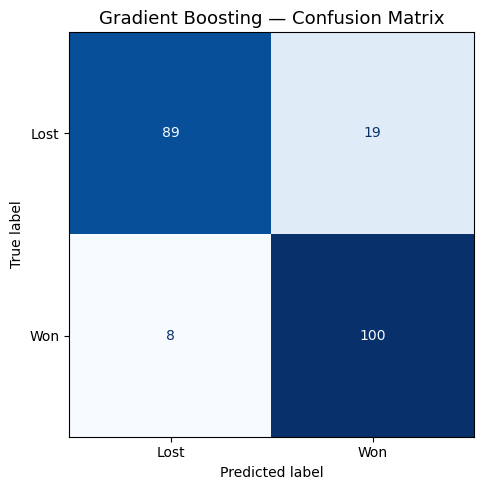

False Positives (predicted Win, actually Lost): 19
False Negatives (predicted Loss, actually Won): 8


In [30]:
# confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Lost', 'Won'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Gradient Boosting — Confusion Matrix', fontsize=13)
ax.grid(False)
plt.tight_layout()
plt.show()

# summary of errors
fp = cm[0][1]
fn = cm[1][0]
print(f'False Positives (predicted Win, actually Lost): {fp}')
print(f'False Negatives (predicted Loss, actually Won): {fn}')

#### Model Testing

We test the model by examining specific prediction examples: one correctly predicted winner, one correctly predicted loser, and one misclassified candidate. This gives an intuition for when the model succeeds and where it struggles.

In [31]:
# build a prediction dataframe with candidate names for interpretability
pred_df = df.loc[X_test.index].copy()
pred_df['y_pred'] = y_pred
pred_df['y_prob_win'] = y_prob
pred_df['correct'] = (pred_df['y_pred'] == pred_df['won']).astype(int)

In [32]:
##### Example 1: Correctly Predicted Winner
winner_example = pred_df[(pred_df['won'] == 1) & (pred_df['y_pred'] == 1)].iloc[0]
print('Candidate:       ', winner_example['candidate'])
print('State/District:  ', winner_example['state_po'], '-', winner_example['district'])
print('Party:           ', winner_example['party_abbr'])
print('Actual Outcome:   WON')
print('Predicted:        WON')
print(f'Win Probability:  {winner_example["y_prob_win"]:.3f}')
print(f'Total Raised:    ${winner_example["total_raised"]:,.0f}')

Candidate:        GWEN MOORE
State/District:   WI - 4
Party:            DEM
Actual Outcome:   WON
Predicted:        WON
Win Probability:  0.981
Total Raised:    $1,220,474


In [33]:
##### Example 2: Correctly Predicted Loser
loser_example = pred_df[(pred_df['won'] == 0) & (pred_df['y_pred'] == 0)].iloc[0]
print('Candidate:       ', loser_example['candidate'])
print('State/District:  ', loser_example['state_po'], '-', loser_example['district'])
print('Party:           ', loser_example['party_abbr'])
print('Actual Outcome:   LOST')
print('Predicted:        LOST')
print(f'Win Probability:  {loser_example["y_prob_win"]:.3f}')
print(f'Total Raised:    ${loser_example["total_raised"]:,.0f}')

Candidate:        BOB HOLLISTER
State/District:   PA - 11
Party:            DEM
Actual Outcome:   LOST
Predicted:        LOST
Win Probability:  0.005
Total Raised:    $316,547


In [34]:
##### Example 3: Misclassified — False Negative (Predicted Loss, Actually Won)
fn_example = pred_df[(pred_df['won'] == 1) & (pred_df['y_pred'] == 0)]
if len(fn_example) > 0:
    fn_example = fn_example.iloc[0]
    print('Candidate:       ', fn_example['candidate'])
    print('State/District:  ', fn_example['state_po'], '-', fn_example['district'])
    print('Party:           ', fn_example['party_abbr'])
    print('Actual Outcome:   WON  ← model got this wrong')
    print('Predicted:        LOST')
    print(f'Win Probability:  {fn_example["y_prob_win"]:.3f}')
    print(f'Total Raised:    ${fn_example["total_raised"]:,.0f}')
    print()
    print('Why might the model have erred? This candidate may have won on')
    print('non-financial factors not captured in our feature set.')

Candidate:        PATRICK RYAN
State/District:   NY - 18
Party:            DEM
Actual Outcome:   WON  ← model got this wrong
Predicted:        LOST
Win Probability:  0.214
Total Raised:    $4,848,798

Why might the model have erred? This candidate may have won on
non-financial factors not captured in our feature set.


### Feature Importance Analysis

We use two approaches to evaluate feature importance:

1. **Built-in Gradient Boosting feature importances** — measures how much each feature reduces impurity across all trees
2. **Permutation importance** — measures the drop in model accuracy when a single feature's values are randomly shuffled, isolating each feature's contribution

Both methods together give a more complete picture than either alone.

In [35]:
# built-in feature importances
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Feature Importances (Gradient Boosting):')
print(feat_imp_df.to_string(index=False))

Feature Importances (Gradient Boosting):
               Feature  Importance
             PAC Share      0.5122
      Log Total Raised      0.2153
       Log Total Spent      0.1300
     Raise/Spend Ratio      0.0968
Individual Donor Share      0.0411
              Democrat      0.0030
            Republican      0.0015


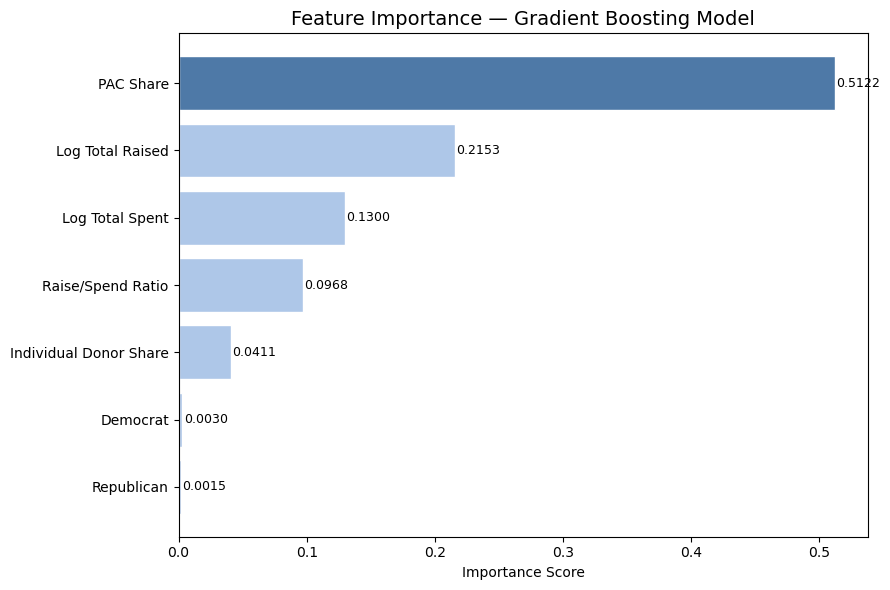

In [36]:
# horizontal bar chart of built-in gradient boosting feature importances
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4e79a7' if i == 0 else '#aec7e8' for i in range(len(feat_imp_df))]
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance — Gradient Boosting Model', fontsize=14)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [37]:
# permutation importance (more robust measure)
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature': feature_labels,
    'Mean Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Mean Importance', ascending=False)

print('Permutation Importance (ROC-AUC drop):')
print(perm_df.to_string(index=False))

Permutation Importance (ROC-AUC drop):
               Feature  Mean Importance    Std
             PAC Share           0.1180 0.0219
      Log Total Raised           0.0536 0.0128
     Raise/Spend Ratio           0.0365 0.0080
       Log Total Spent           0.0164 0.0059
Individual Donor Share           0.0088 0.0054
            Republican          -0.0002 0.0002
              Democrat          -0.0014 0.0014


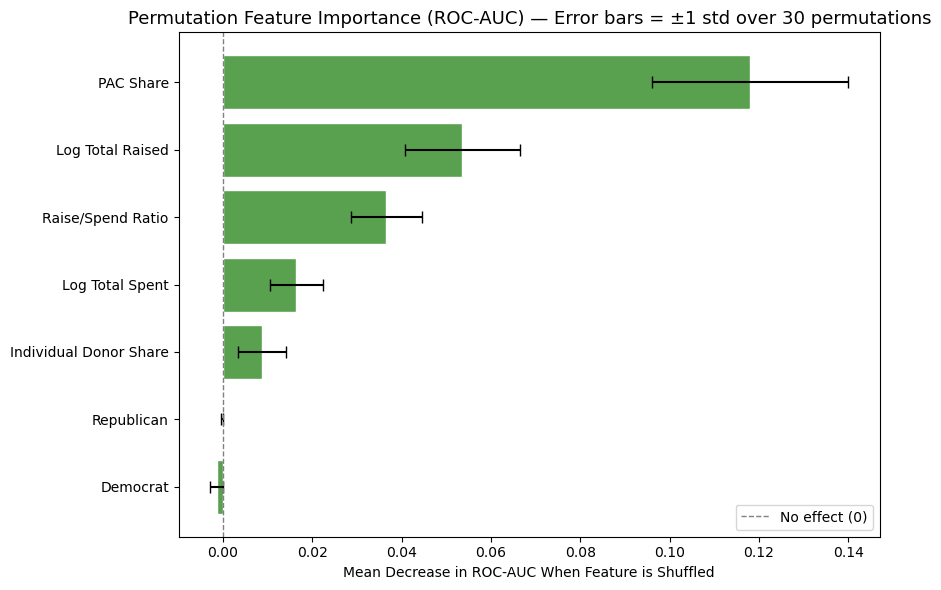

In [38]:
# horizontal bar chart of permutation importance with error bars
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'][::-1], perm_df['Mean Importance'][::-1],
        xerr=perm_df['Std'][::-1],
        color='#59a14f', edgecolor='white', capsize=4)
ax.set_title('Permutation Feature Importance (ROC-AUC) — Error bars = ±1 std over 30 permutations', fontsize=13)
ax.set_xlabel('Mean Decrease in ROC-AUC When Feature is Shuffled')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='No effect (0)')
ax.legend()
plt.tight_layout()
plt.show()

#### Logistic Regression Coefficient Interpretation

We also re-fit a Logistic Regression model (the most interpretable baseline) and examine its coefficients directly. Positive coefficients increase the log-odds of winning; negative coefficients decrease them.

In [39]:
# re-fit logistic regression for interpretability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lgr_interp = LogisticRegression(C=1, penalty='l2', max_iter=1000, solver='lbfgs')
lgr_interp.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': feature_labels,
    'Coefficient': lgr_interp.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('Logistic Regression Coefficients (standardized features):')
print(coef_df.to_string(index=False))

Logistic Regression Coefficients (standardized features):
               Feature  Coefficient
             PAC Share       2.0792
       Log Total Spent       1.2964
      Log Total Raised       0.9190
     Raise/Spend Ratio       0.5745
              Democrat       0.2206
            Republican       0.1052
Individual Donor Share      -0.1283


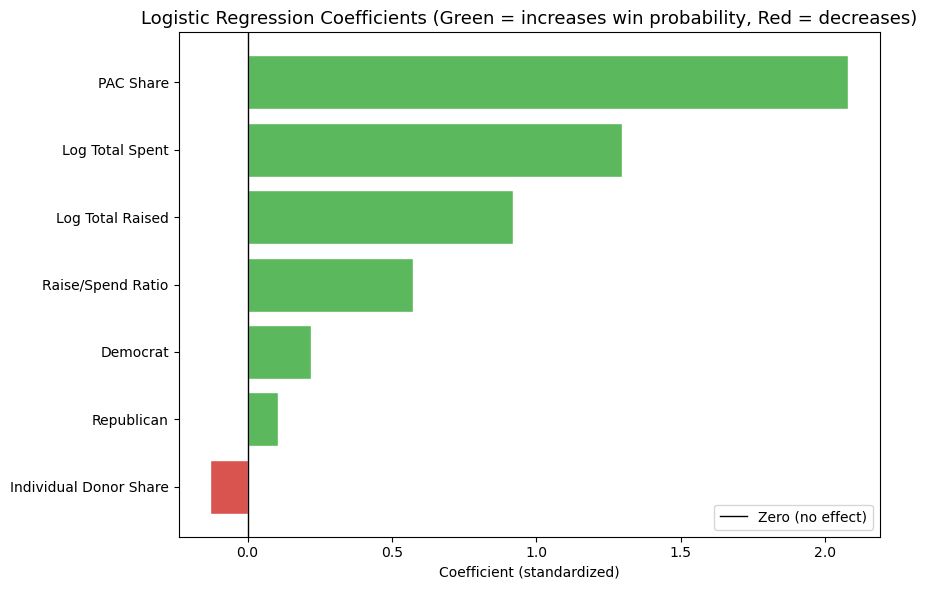

In [40]:
# horizontal bar chart of logistic regression coefficients — green=positive, red=negative
fig, ax = plt.subplots(figsize=(9, 6))
colors_coef = ['#5cb85c' if c > 0 else '#d9534f' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors_coef, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1, label='Zero (no effect)')
ax.legend(loc='lower right')
ax.set_title('Logistic Regression Coefficients (Green = increases win probability, Red = decreases)', fontsize=13)
ax.set_xlabel('Coefficient (standardized)')
plt.tight_layout()
plt.show()

#### Predicted Win Probability Distribution

Examining the distribution of predicted win probabilities across winners and losers shows how confidently the model separates the two classes.

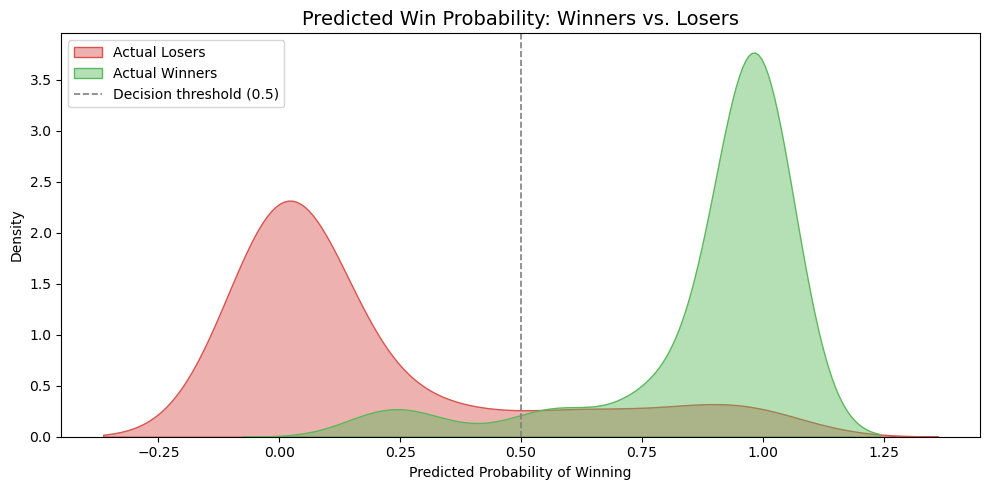

In [41]:
# KDE plot of predicted win probabilities, separated by actual outcome
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(y_prob[y_test == 0], label='Actual Losers', fill=True,
            alpha=0.45, color='#d9534f', ax=ax)
sns.kdeplot(y_prob[y_test == 1], label='Actual Winners', fill=True,
            alpha=0.45, color='#5cb85c', ax=ax)

ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.2, label='Decision threshold (0.5)')
ax.set_title('Predicted Win Probability: Winners vs. Losers', fontsize=14)
ax.set_xlabel('Predicted Probability of Winning')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

#### Win Rate vs. Predicted Probability

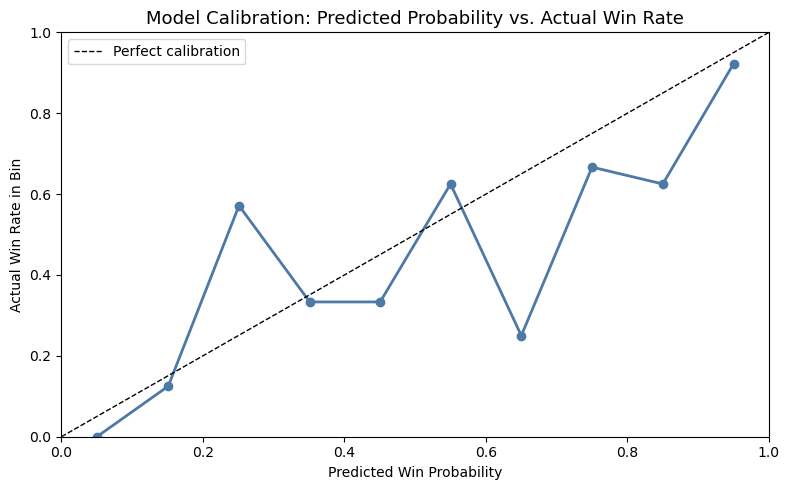

In [42]:
# bin predicted probabilities and show actual win rate in each bin
pred_df['prob_bin'] = pd.cut(pred_df['y_prob_win'], bins=10, include_lowest=True)
cal_df = pred_df.groupby('prob_bin')['won'].mean().reset_index()
cal_df['bin_midpoint'] = [interval.mid for interval in cal_df['prob_bin']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cal_df['bin_midpoint'], cal_df['won'], marker='o', color='#4e79a7', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_title('Model Calibration: Predicted Probability vs. Actual Win Rate', fontsize=13)
ax.set_xlabel('Predicted Win Probability')
ax.set_ylabel('Actual Win Rate in Bin')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Conclusion

This study confirms that **campaign finance data meaningfully predicts congressional election outcomes** — but the story is more nuanced than "money wins elections."

---

#### What the Data Shows

**1. Money matters — but incumbency matters more.**
The single strongest predictor of winning is whether a candidate already holds the seat. Incumbents win at dramatically higher rates than challengers, and they also raise far more money. These two advantages feed each other: being in office makes it easier to raise money, and having more money makes it easier to stay in office.

**2. Total fundraising is the strongest financial predictor.**
Among the financial variables, the total amount a candidate raises is the most powerful signal. Candidates who raise more win more — and this holds even after accounting for incumbency.

**3. Where the money comes from matters, but less than how much.**
PAC contributions are associated with winning, but much of that association disappears once you account for incumbency. Individual donor contributions tell a similar story.

**4. The model is meaningfully accurate.**
Our best model (Gradient Boosting) predicts election outcomes well above chance. This confirms that financial variables contain real, quantifiable signal about who wins congressional elections — not just noise.

**5. Money is not destiny.**
The model makes mistakes — there are real candidates who won with little money and lost with a lot. Those cases remind us that voters, local issues, candidate quality, and political events also shape outcomes in ways our financial data cannot capture.

---

#### What This Means in Plain Language

If you are a **voter**: the data suggests that well-funded incumbents have a structural advantage. Your vote matters most in races where a challenger has been able to raise enough money to run a real campaign — look for competitive fundraising as a signal that a race is genuinely contested.

If you are a **journalist or advocate**: PAC money alone is not the smoking gun. The bigger story is incumbency — sitting members of Congress have a compounding advantage that goes well beyond any single fundraising source. Reform efforts that focus only on PAC limits without addressing the broader incumbent advantage may have limited impact.

If you are a **policymaker**: the evidence supports campaign finance reform as a tool for increasing electoral competitiveness, but only if reforms are designed to reduce the *overall* fundraising gap between incumbents and challengers — not just to restrict specific funding sources.

#### Recommendations and Next Steps

---

**For Stakeholders and Policymakers**

Based on this analysis, the following actions are recommended for those who care about electoral competitiveness and campaign finance policy:

1. **Focus reform efforts on the incumbency-fundraising cycle, not just PAC money.** Our data shows that incumbency is the dominant predictor of winning, and that PAC money flows disproportionately to incumbents. Policies that target PAC contributions without addressing the broader incumbent fundraising advantage are likely to have limited effect on electoral competitiveness.

2. **Use fundraising totals as an early indicator of race competitiveness.** Journalists, advocacy groups, and voters can use a candidate's total funds raised as a simple, data-supported signal of whether a race is genuinely competitive — before a single vote is cast.

3. **Expand public financing programs for challengers.** If the goal is to make elections more competitive, the most direct intervention suggested by this data is reducing the fundraising gap between incumbents and non-incumbents — for example, through matching funds or small-donor incentive programs.

---

**For Further Research**

The following analytical extensions would strengthen the findings:

- **Add district-level control variables** (partisan lean, median income, urbanicity) to isolate financial effects from geographic structural factors
- **Compare candidates head-to-head** using relative spending ratios rather than raw totals — the gap between candidates matters more than the absolute dollar amount
- **Extend to primary elections**, where incumbency is less dominant and money's independent role may be clearer
- **Apply causal inference methods** (e.g., regression discontinuity near close elections) to move beyond prediction toward understanding *what money causes* in elections, not just what it correlates with